In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

for root, dirs, files in os.walk('/content/drive'):
    for file in files:
        if file == 'decentraland_dataset.csv':
            print(os.path.join(root, file))

/content/drive/MyDrive/decentraland_dataset.csv


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/decentraland_dataset.csv"

df = pd.read_csv(file_path)

print(df.shape)
df.head()

(2000, 15)


,Unnamed: 0,contract address,Token_id,sales_price,timestamp,owner_id,bids_count,sales_count,parcels_list,parcels_count,status (label),"adjacency [road, district, plaza]",coordination-est,mana_price,land_price
0,0,0xf87e31492faf9a91b02ee0deaad50d51d56d5d4d,7145929705339707732730866756067132440644,6549000000000000000000,1642942635000,0xda3374ebd805b3d2aa6ee2bc5fcb6d9cc00667e3,3,3,"['21,68']",1,parcel,"[[8, 3, 0]]","[21.0, 68.0]",2.119167,1.387843e+22
1,1,0xf87e31492faf9a91b02ee0deaad50d51d56d5d4d,1157920892373161954235709850086879078474851844...,5387000000000000000000,1643751407000,0x862364e32c4a03fc84c612040657e94927fc3e81,0,1,"['-17,40']",1,parcel,"[[1, 0, 0]]","[-17.0, 40.0]",2.697335,1.453054e+22
2,2,0xf87e31492faf9a91b02ee0deaad50d51d56d5d4d,1157920892373161954235709850086879078277488071...,5299000000000000000000,1642752884000,0x8c593534cc44d3cbb8bde927597611d30f56792b,0,1,"['-76,-44']",1,parcel,"[[5, 0, 7]]","[-76.0, -44.0]",2.636088,1.396863e+22
3,3,0xf87e31492faf9a91b02ee0deaad50d51d56d5d4d,1157920892373161954235709850086879078393184076...,8887000000000000000000,1643885971000,0xe6dcf90f6486978ea42bb68f69653111875105de,0,2,"['-136,-37', '-41,90', '-41,89', '-37,89']",4,road,"[[0, 0, 0], [3, 5, 0], [3, 5, 0], [3, 5, 0]]","[-63.75, 57.75]",2.559175,2.274339e+22
4,4,0xf87e31492faf9a91b02ee0deaad50d51d56d5d4d,11569600475311907757754736652680119189479,6800000000000000000000,1644600068000,0x959e104e1a4db6317fa58f8295f586e1a978c297,3,3,[],0,NaN,[],[0],2.934938,1.995758e+22


In [ ]:
df.columns

Index(['Unnamed: 0', 'contract address', 'Token_id', 'sales_price',
       'timestamp', 'owner_id', 'bids_count', 'sales_count', 'parcels_list',
       'parcels_count', 'status (label)', 'adjacency [road, district, plaza]',
       'coordination-est', 'mana_price', 'land_price'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         2000 non-null   int64  
 1   contract address                   2000 non-null   object 
 2   Token_id                           2000 non-null   object 
 3   sales_price                        2000 non-null   object 
 4   timestamp                          2000 non-null   int64  
 5   owner_id                           2000 non-null   object 
 6   bids_count                         2000 non-null   int64  
 7   sales_count                        2000 non-null   int64  
 8   parcels_list                       2000 non-null   object 
 9   parcels_count                      2000 non-null   int64  
 10  status (label)                     1860 non-null   object 
 11  adjacency [road, district, plaza]  2000 non-null   objec

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
contract address,0
Token_id,0
sales_price,0
timestamp,0
owner_id,0
bids_count,0
sales_count,0
parcels_list,0
parcels_count,0


In [ ]:
import numpy as np
import pandas as pd
import ast
import re

df_model = df.copy()

# Drop index column
df_model = df_model.drop(columns=["Unnamed: 0"], errors="ignore")

# Convert sales_price to numeric
df_model["sales_price"] = pd.to_numeric(df_model["sales_price"], errors="coerce")

# Convert timestamp
df_model["timestamp"] = pd.to_datetime(df_model["timestamp"], unit="ms", errors="coerce")

# Fill missing status
df_model["status (label)"] = df_model["status (label)"].fillna("unknown")

# Remove invalid rows
df_model = df_model.dropna(subset=["sales_price", "timestamp"])

# Create target
df_model["log_sales_price"] = np.log1p(df_model["sales_price"])

print(df_model.shape)
df_model[["sales_price", "timestamp", "status (label)", "log_sales_price"]].head()

(2000, 15)


,sales_price,timestamp,status (label),log_sales_price
0,6.549000e+21,2022-01-23 12:57:15,parcel,50.233599
1,5.387000e+21,2022-02-01 21:36:47,parcel,50.038276
2,5.299000e+21,2022-01-21 08:14:44,parcel,50.021805
3,8.887000e+21,2022-02-03 10:59:31,road,50.538876
4,6.800000e+21,2022-02-11 17:21:08,unknown,50.271210


In [ ]:
# Convert sales price from WEI to ETH
df_model["sales_price_eth"] = df_model["sales_price"] / 1e18

# Create log target using ETH price
df_model["log_sales_price_eth"] = np.log1p(df_model["sales_price_eth"])

df_model[["sales_price", "sales_price_eth", "timestamp", "status (label)", "log_sales_price_eth"]].head()

,sales_price,sales_price_eth,timestamp,status (label),log_sales_price_eth
0,6.549000e+21,6549.0,2022-01-23 12:57:15,parcel,8.787220
1,5.387000e+21,5387.0,2022-02-01 21:36:47,parcel,8.591930
2,5.299000e+21,5299.0,2022-01-21 08:14:44,parcel,8.575462
3,8.887000e+21,8887.0,2022-02-03 10:59:31,road,9.092457
4,6.800000e+21,6800.0,2022-02-11 17:21:08,unknown,8.824825


In [ ]:
log_sales_price_eth

NameError: name 'log_sales_price_eth' is not defined

In [ ]:
# Create time-based features from the timestamp
df_model["year"] = df_model["timestamp"].dt.year
df_model["month"] = df_model["timestamp"].dt.month
df_model["quarter"] = df_model["timestamp"].dt.quarter
df_model["dayofweek"] = df_model["timestamp"].dt.dayofweek

# Weekend flag: 1 if Saturday/Sunday, else 0
df_model["is_weekend"] = df_model["dayofweek"].isin([5, 6]).astype(int)

df_model[["timestamp", "year", "month", "quarter", "dayofweek", "is_weekend"]].head()

,timestamp,year,month,quarter,dayofweek,is_weekend
0,2022-01-23 12:57:15,2022,1,1,6,1
1,2022-02-01 21:36:47,2022,2,1,1,0
2,2022-01-21 08:14:44,2022,1,1,4,0
3,2022-02-03 10:59:31,2022,2,1,3,0
4,2022-02-11 17:21:08,2022,2,1,4,0


In [ ]:
import ast

def parse_adjacency(val):
    try:
        arr = ast.literal_eval(str(val))
        road = sum(x[0] for x in arr) if len(arr) > 0 else 0
        district = sum(x[1] for x in arr) if len(arr) > 0 else 0
        plaza = sum(x[2] for x in arr) if len(arr) > 0 else 0
        adjacency_count = len(arr)
        return pd.Series([road, district, plaza, adjacency_count])
    except:
        return pd.Series([0, 0, 0, 0])

df_model[["road_adj", "district_adj", "plaza_adj", "adjacency_count"]] = (
    df_model["adjacency [road, district, plaza]"].apply(parse_adjacency)
)

df_model[[
    "adjacency [road, district, plaza]",
    "road_adj",
    "district_adj",
    "plaza_adj",
    "adjacency_count"
]].head()

,"adjacency [road, district, plaza]",road_adj,district_adj,plaza_adj,adjacency_count
0,"[[8, 3, 0]]",8,3,0,1
1,"[[1, 0, 0]]",1,0,0,1
2,"[[5, 0, 7]]",5,0,7,1
3,"[[0, 0, 0], [3, 5, 0], [3, 5, 0], [3, 5, 0]]",9,15,0,4
4,[],0,0,0,0


In [ ]:
import re

def parse_coords(val):
    nums = re.findall(r"-?\d+", str(val))
    if len(nums) >= 2:
        x = int(nums[0])
        y = int(nums[1])
        return pd.Series([x, y])
    return pd.Series([np.nan, np.nan])

df_model[["coord_x", "coord_y"]] = df_model["coordination-est"].apply(parse_coords)

df_model["distance_from_center"] = np.sqrt(df_model["coord_x"]**2 + df_model["coord_y"]**2)
df_model["manhattan_distance"] = abs(df_model["coord_x"]) + abs(df_model["coord_y"])

df_model[[
    "coordination-est",
    "coord_x",
    "coord_y",
    "distance_from_center",
    "manhattan_distance"
]].head()

,coordination-est,coord_x,coord_y,distance_from_center,manhattan_distance
0,"[21.0, 68.0]",21.0,0.0,21.000000,21.0
1,"[-17.0, 40.0]",-17.0,0.0,17.000000,17.0
2,"[-76.0, -44.0]",-76.0,0.0,76.000000,76.0
3,"[-63.75, 57.75]",-63.0,75.0,97.948966,138.0
4,[0],NaN,NaN,NaN,NaN


In [ ]:
def parse_coords_fixed(val):
    nums = re.findall(r"-?\d+\.?\d*", str(val))
    if len(nums) >= 2:
        x = float(nums[0])
        y = float(nums[1])
        return pd.Series([x, y])
    return pd.Series([np.nan, np.nan])

df_model[["coord_x", "coord_y"]] = df_model["coordination-est"].apply(parse_coords_fixed)

df_model["distance_from_center"] = np.sqrt(df_model["coord_x"]**2 + df_model["coord_y"]**2)
df_model["manhattan_distance"] = abs(df_model["coord_x"]) + abs(df_model["coord_y"])

df_model[[
    "coordination-est",
    "coord_x",
    "coord_y",
    "distance_from_center",
    "manhattan_distance"
]].head()

,coordination-est,coord_x,coord_y,distance_from_center,manhattan_distance
0,"[21.0, 68.0]",21.00,68.00,71.168813,89.0
1,"[-17.0, 40.0]",-17.00,40.00,43.462628,57.0
2,"[-76.0, -44.0]",-76.00,-44.00,87.817994,120.0
3,"[-63.75, 57.75]",-63.75,57.75,86.018167,121.5
4,[0],NaN,NaN,NaN,NaN


In [ ]:
# Sort data by time so older sales come first and newer sales come last
df_model = df_model.sort_values("timestamp").reset_index(drop=True)

# Select features for the model
features = [
    "bids_count",
    "sales_count",
    "parcels_count",
    "status (label)",
    "year",
    "month",
    "quarter",
    "dayofweek",
    "is_weekend",
    "road_adj",
    "district_adj",
    "plaza_adj",
    "adjacency_count",
    "coord_x",
    "coord_y",
    "distance_from_center",
    "manhattan_distance"
]

X = df_model[features]
y = df_model["log_sales_price_eth"]


split_index = int(len(df_model) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train period:", df_model["timestamp"].iloc[:split_index].min(), "to", df_model["timestamp"].iloc[:split_index].max())
print("Test period:", df_model["timestamp"].iloc[split_index:].min(), "to", df_model["timestamp"].iloc[split_index:].max())
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

Train period: 2021-12-21 12:51:16 to 2022-02-05 19:58:44
Test period: 2022-02-05 19:58:44 to 2022-03-03 13:06:05
X_train: (1600, 17)
X_test: (400, 17)


In [ ]:
!pip install xgboost -q

from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

numeric_features = [
    "bids_count", "sales_count", "parcels_count",
    "year", "month", "quarter", "dayofweek", "is_weekend",
    "road_adj", "district_adj", "plaza_adj", "adjacency_count",
    "coord_x", "coord_y", "distance_from_center", "manhattan_distance"
]

categorical_features = ["status (label)"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

time_xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", xgb_model)
])

time_xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['bids_count', 'sales_count',
                                                   'parcels_count', 'year',
                                                   'month', 'quarter',
                                                   'dayofweek', 'is_weekend',
                                                   'road_adj', 'district_adj',
                                                   'plaza_adj',
                                                   'adjacency_count', 'coord_x',
                                                   'coord_y',
                                                   'distance_from_center',
                                                   'manhattan_distance']),
                                                 ('cat',
                                                  OneHotEncoder(handle_un...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [ ]:
y_pred_log = time_xgb_pipeline.predict(X_test)

rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae_log = mean_absolute_error(y_test, y_pred_log)
r2 = r2_score(y_test, y_pred_log)

print("Time-Based XGBoost Results")
print("RMSE Log:", rmse_log)
print("MAE Log:", mae_log)
print("R2:", r2)

Time-Based XGBoost Results
RMSE Log: 0.8707667176597346
MAE Log: 0.4182963541744742
R2: 0.11310326940861637


In [ ]:
y_test_price = np.expm1(y_test)
y_pred_price = np.expm1(y_pred_log)

mae_price = mean_absolute_error(y_test_price, y_pred_price)
rmse_price = np.sqrt(mean_squared_error(y_test_price, y_pred_price))

print("MAE in ETH:", mae_price)
print("RMSE in ETH:", rmse_price)

MAE in ETH: 4878.159380340576
RMSE in ETH: 17027.873172717427


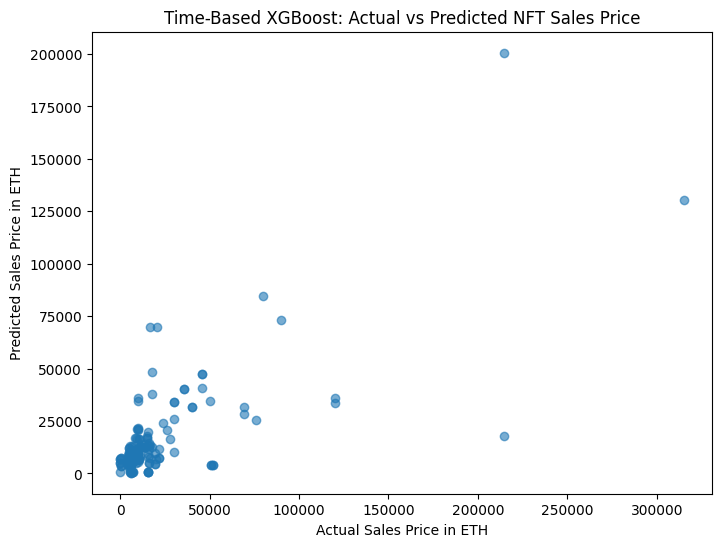

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test_price, y_pred_price, alpha=0.6)
plt.xlabel("Actual Sales Price in ETH")
plt.ylabel("Predicted Sales Price in ETH")
plt.title("Time-Based XGBoost: Actual vs Predicted NFT Sales Price")
plt.show()

Autoregression needs a time series, not individual rows.

So we convert your transaction data into:

daily average NFT sales price in ETH

That means each date has one average price value.

In [ ]:
daily_prices = (
    df_model
    .set_index("timestamp")
    .resample("D")["sales_price_eth"]
    .mean()
    .dropna()
)

print(daily_prices.head())
print("Total days:", len(daily_prices))

timestamp
2021-12-21    14334.789474
2021-12-22     7084.419355
2021-12-23     6645.000000
2021-12-24     7594.400000
2021-12-25     7779.307692
Freq: D, Name: sales_price_eth, dtype: float64
Total days: 73


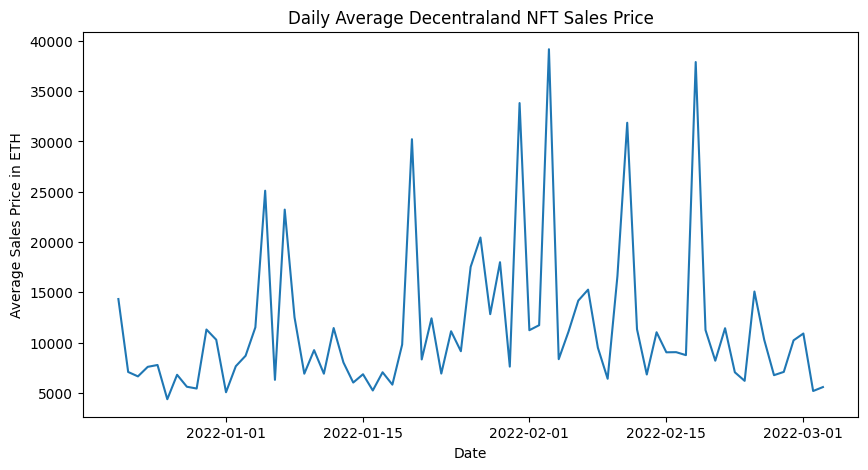

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(daily_prices)
plt.xlabel("Date")
plt.ylabel("Average Sales Price in ETH")
plt.title("Daily Average Decentraland NFT Sales Price")
plt.show()

This plot shows the NFT price series is very volatile with sharp spikes, which supports
 research point that NFT prices are hard to forecast.

In [ ]:
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Use log-transformed daily prices for stability
daily_log_prices = np.log1p(daily_prices)

# Time-based split: first 80% train, last 20% test
train_size = int(len(daily_log_prices) * 0.8)

train_ar = daily_log_prices.iloc[:train_size]
test_ar = daily_log_prices.iloc[train_size:]

# Build AutoRegressive model using previous 7 days
ar_model = AutoReg(train_ar, lags=7).fit()

# Predict test period
ar_pred_log = ar_model.predict(
    start=len(train_ar),
    end=len(train_ar) + len(test_ar) - 1
)

# Evaluation on log scale
ar_rmse_log = np.sqrt(mean_squared_error(test_ar, ar_pred_log))
ar_mae_log = mean_absolute_error(test_ar, ar_pred_log)
ar_r2 = r2_score(test_ar, ar_pred_log)

print("AutoRegressive Model Results")
print("RMSE Log:", ar_rmse_log)
print("MAE Log:", ar_mae_log)
print("R2:", ar_r2)

AutoRegressive Model Results
RMSE Log: 0.48018692425425114
MAE Log: 0.35285725911701654
R2: -0.02846473870545041


The autoregressive model produced a negative R², suggesting that historical daily average prices alone do not provide enough information to accurately forecast future Decentraland NFT prices. This supports the argument that NFT market predictability requires more than simple past-price patterns and may depend on additional features such as parcel characteristics, spatial location, market activity, and liquidity.

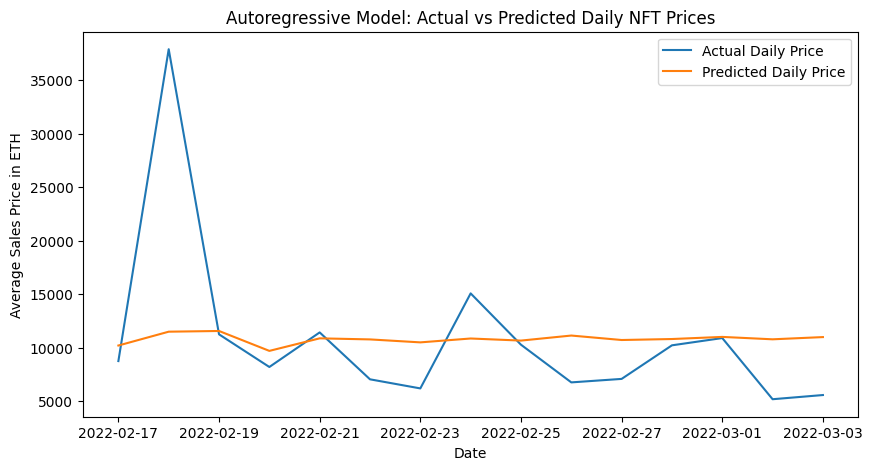

In [ ]:
# Convert AR predictions back from log scale to ETH
test_ar_price = np.expm1(test_ar)
ar_pred_price = np.expm1(ar_pred_log)

# Plot actual vs predicted daily prices
plt.figure(figsize=(10,5))
plt.plot(test_ar_price.index, test_ar_price, label="Actual Daily Price")
plt.plot(test_ar_price.index, ar_pred_price, label="Predicted Daily Price")
plt.xlabel("Date")
plt.ylabel("Average Sales Price in ETH")
plt.title("Autoregressive Model: Actual vs Predicted Daily NFT Prices")
plt.legend()
plt.show()

The autoregressive plot shows that the model predicts a relatively smooth price trend, while actual Decentraland NFT prices fluctuate sharply. The model fails to capture sudden price spikes, especially the large increase around February 18. This explains the negative R² result and shows that historical daily prices alone are not sufficient for reliable NFT price forecasting.

This supports the project’s main argument that NFT markets are highly volatile and only conditionally predictable. More detailed features such as parcel location, adjacency, transaction activity, and market behavior are needed for better prediction.

**CatBoost Model**

In [ ]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


cat_features = ["status (label)"]

cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

cat_pred_log = cat_model.predict(X_test)

cat_rmse_log = np.sqrt(mean_squared_error(y_test, cat_pred_log))
cat_mae_log = mean_absolute_error(y_test, cat_pred_log)
cat_r2 = r2_score(y_test, cat_pred_log)

print("Time-Based CatBoost Results")
print("RMSE Log:", cat_rmse_log)
print("MAE Log:", cat_mae_log)
print("R2:", cat_r2)

0:	learn: 0.9579971	total: 56.1ms	remaining: 28s
100:	learn: 0.5979092	total: 291ms	remaining: 1.15s
200:	learn: 0.5403272	total: 526ms	remaining: 782ms
300:	learn: 0.5047461	total: 764ms	remaining: 505ms
400:	learn: 0.4766335	total: 1.03s	remaining: 254ms
499:	learn: 0.4500608	total: 1.26s	remaining: 0us
Time-Based CatBoost Results
RMSE Log: 0.8070245583668912
MAE Log: 0.4036947362544396
R2: 0.2381965882317868


### Time-Based CatBoost Model Result

The CatBoost model was trained using the same chronological split as the time-based XGBoost model, where older NFT sales were used for training and newer sales were used for testing. CatBoost achieved an R² of 0.238, outperforming the time-based XGBoost model, which had an R² of 0.113.

This improvement suggests that CatBoost handled the mixed structure of the dataset more effectively, especially the categorical feature `status (label)`. However, the R² is still moderate, showing that future NFT price prediction remains difficult due to market volatility, speculative behavior, and extreme price outliers.

Overall, CatBoost is currently the strongest forward-looking model in this section.

In [ ]:
cat_test_price = np.expm1(y_test)
cat_pred_price = np.expm1(cat_pred_log)

cat_mae_price = mean_absolute_error(cat_test_price, cat_pred_price)
cat_rmse_price = np.sqrt(mean_squared_error(cat_test_price, cat_pred_price))

print("CatBoost MAE in ETH:", cat_mae_price)
print("CatBoost RMSE in ETH:", cat_rmse_price)

CatBoost MAE in ETH: 5437.819968553141
CatBoost RMSE in ETH: 19990.61441667357


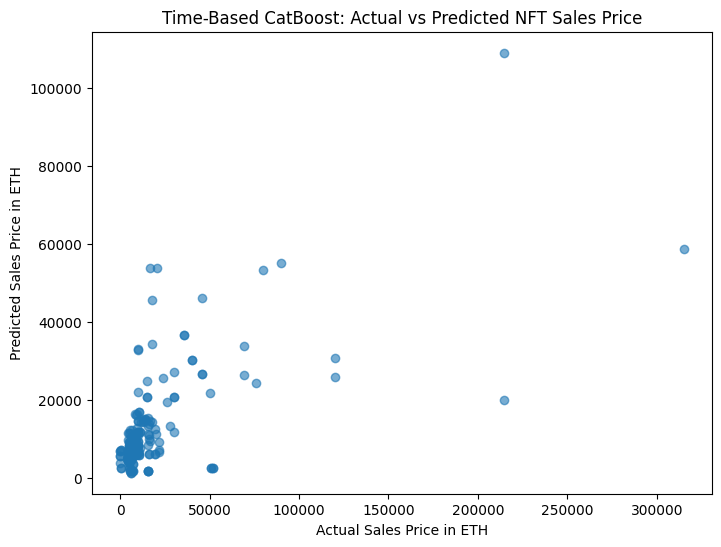

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(cat_test_price, cat_pred_price, alpha=0.6)
plt.xlabel("Actual Sales Price in ETH")
plt.ylabel("Predicted Sales Price in ETH")
plt.title("Time-Based CatBoost: Actual vs Predicted NFT Sales Price")
plt.show()

The CatBoost actual vs predicted plot shows that the model captures the general lower-price range better than extreme high-value NFT sales. Most observations are clustered near the lower end, while a few rare expensive transactions create large errors. This explains why the R² improved compared to time-based XGBoost, but MAE and RMSE in ETH remain high.

Overall, CatBoost is the strongest forward-looking model tested so far, but the plot confirms that Decentraland NFT prices are still difficult to predict accurately because of volatility and extreme outliers.

LightGBM with lag/rolling

In [ ]:
!pip install lightgbm -q

In [ ]:
# Create date column
df_lgbm = df_model.copy()
df_lgbm["date"] = df_lgbm["timestamp"].dt.date

# Daily market price series
daily_market = (
    df_lgbm.groupby("date")["sales_price_eth"]
    .mean()
    .reset_index()
    .rename(columns={"sales_price_eth": "daily_avg_price_eth"})
)

# Create lag and rolling features using ONLY past prices
daily_market["lag_1_day_price"] = daily_market["daily_avg_price_eth"].shift(1)
daily_market["lag_3_day_price"] = daily_market["daily_avg_price_eth"].shift(3)

daily_market["rolling_3_day_avg"] = daily_market["daily_avg_price_eth"].shift(1).rolling(3).mean()
daily_market["rolling_7_day_avg"] = daily_market["daily_avg_price_eth"].shift(1).rolling(7).mean()

daily_market["rolling_3_day_std"] = daily_market["daily_avg_price_eth"].shift(1).rolling(3).std()
daily_market["rolling_7_day_std"] = daily_market["daily_avg_price_eth"].shift(1).rolling(7).std()

# Merge these market-memory features back into transaction-level data
df_lgbm = df_lgbm.merge(daily_market, on="date", how="left")

df_lgbm[[
    "date",
    "sales_price_eth",
    "lag_1_day_price",
    "rolling_3_day_avg",
    "rolling_7_day_avg",
    "rolling_3_day_std",
    "rolling_7_day_std"
]].head(10)

,date,sales_price_eth,lag_1_day_price,rolling_3_day_avg,rolling_7_day_avg,rolling_3_day_std,rolling_7_day_std
0,2021-12-21,4200.0,NaN,NaN,NaN,NaN,NaN
1,2021-12-21,4850.0,NaN,NaN,NaN,NaN,NaN
2,2021-12-21,4360.0,NaN,NaN,NaN,NaN,NaN
3,2021-12-21,5675.0,NaN,NaN,NaN,NaN,NaN
4,2021-12-21,4150.0,NaN,NaN,NaN,NaN,NaN
5,2021-12-21,40000.0,NaN,NaN,NaN,NaN,NaN
6,2021-12-21,4150.0,NaN,NaN,NaN,NaN,NaN
7,2021-12-21,4450.0,NaN,NaN,NaN,NaN,NaN
8,2021-12-21,56000.0,NaN,NaN,NaN,NaN,NaN
9,2021-12-21,4800.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Drop rows where lag/rolling features are not available yet
df_lgbm = df_lgbm.dropna(subset=[
    "lag_1_day_price",
    "lag_3_day_price",
    "rolling_3_day_avg",
    "rolling_7_day_avg",
    "rolling_3_day_std",
    "rolling_7_day_std"
])

# Sort by timestamp for time-based split
df_lgbm = df_lgbm.sort_values("timestamp").reset_index(drop=True)

print("Shape after adding lag/rolling features:", df_lgbm.shape)
df_lgbm[[
    "timestamp",
    "sales_price_eth",
    "lag_1_day_price",
    "rolling_3_day_avg",
    "rolling_7_day_avg",
    "rolling_3_day_std",
    "rolling_7_day_std"
]].head()

Shape after adding lag/rolling features: (1875, 38)


,timestamp,sales_price_eth,lag_1_day_price,rolling_3_day_avg,rolling_7_day_avg,rolling_3_day_std,rolling_7_day_std
0,2021-12-28 01:22:28,16500.0,6806.181818,6320.710789,7802.963028,1752.510652,3090.286958
1,2021-12-28 01:43:06,3888.0,6806.181818,6320.710789,7802.963028,1752.510652,3090.286958
2,2021-12-28 03:08:52,3888.0,6806.181818,6320.710789,7802.963028,1752.510652,3090.286958
3,2021-12-28 04:26:09,4270.0,6806.181818,6320.710789,7802.963028,1752.510652,3090.286958
4,2021-12-28 04:31:15,5888.0,6806.181818,6320.710789,7802.963028,1752.510652,3090.286958


In [ ]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lgbm_features = [
    "bids_count",
    "sales_count",
    "parcels_count",
    "year",
    "month",
    "quarter",
    "dayofweek",
    "is_weekend",
    "road_adj",
    "district_adj",
    "plaza_adj",
    "adjacency_count",
    "coord_x",
    "coord_y",
    "distance_from_center",
    "manhattan_distance",
    "lag_1_day_price",
    "lag_3_day_price",
    "rolling_3_day_avg",
    "rolling_7_day_avg",
    "rolling_3_day_std",
    "rolling_7_day_std"
]

X_lgbm = df_lgbm[lgbm_features]
y_lgbm = df_lgbm["log_sales_price_eth"]

split_index = int(len(df_lgbm) * 0.8)

X_train_lgbm = X_lgbm.iloc[:split_index]
X_test_lgbm = X_lgbm.iloc[split_index:]

y_train_lgbm = y_lgbm.iloc[:split_index]
y_test_lgbm = y_lgbm.iloc[split_index:]

lgbm_model = LGBMRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=5,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm_model.fit(X_train_lgbm, y_train_lgbm)

lgbm_pred_log = lgbm_model.predict(X_test_lgbm)

lgbm_rmse_log = np.sqrt(mean_squared_error(y_test_lgbm, lgbm_pred_log))
lgbm_mae_log = mean_absolute_error(y_test_lgbm, lgbm_pred_log)
lgbm_r2 = r2_score(y_test_lgbm, lgbm_pred_log)

print("Time-Based LightGBM with Lag/Rolling Features")
print("RMSE Log:", lgbm_rmse_log)
print("MAE Log:", lgbm_mae_log)
print("R2:", lgbm_r2)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000954 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1427
[LightGBM] [Info] Number of data points in the train set: 1500, number of used features: 22
[LightGBM] [Info] Start training from score 8.818571
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

### Time-Based LightGBM with Lag/Rolling Features

The LightGBM model was built to improve future NFT price prediction by adding lag and rolling market features. Unlike earlier models that only used parcel, location, and transaction-level features, this model also included recent market behavior such as previous-day average price, 3-day and 7-day rolling averages, and rolling volatility.

The model achieved an R² of 0.445, which is the strongest result among the time-based models. This suggests that recent market conditions are important predictors of Decentraland NFT sale prices. The improvement also shows that NFT prices are not completely random, but their predictability depends heavily on market-memory signals.

However, prediction remains imperfect because NFT markets still contain extreme price outliers and speculative behavior.

In [ ]:
lgbm_test_price = np.expm1(y_test_lgbm)
lgbm_pred_price = np.expm1(lgbm_pred_log)

lgbm_mae_price = mean_absolute_error(lgbm_test_price, lgbm_pred_price)
lgbm_rmse_price = np.sqrt(mean_squared_error(lgbm_test_price, lgbm_pred_price))

print("LightGBM MAE in ETH:", lgbm_mae_price)
print("LightGBM RMSE in ETH:", lgbm_rmse_price)

LightGBM MAE in ETH: 5577.835060980892
LightGBM RMSE in ETH: 20196.73546137685


Although LightGBM achieved the best R² score among the time-based models, the MAE and RMSE in ETH remain high. This is because Decentraland NFT prices contain extreme high-value sales, and even a few large outliers can heavily increase price-scale error. Therefore, the log-scale metrics are more reliable for comparing models, while ETH-scale metrics show the real-world difficulty of predicting rare expensive NFT transactions.

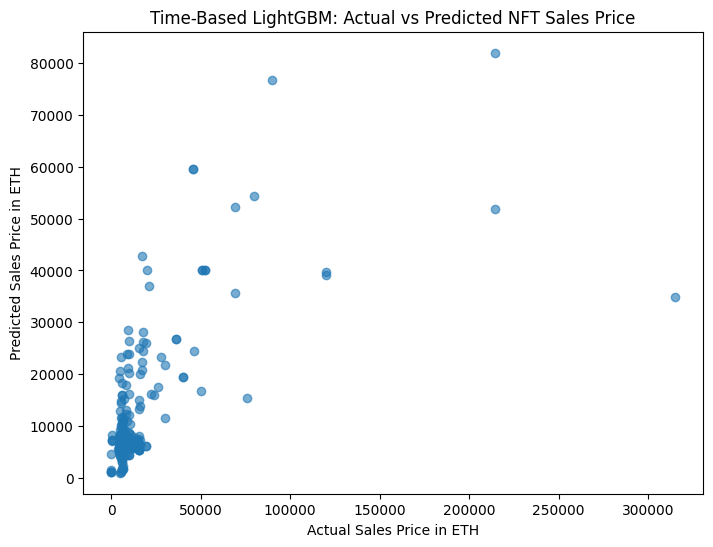

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(lgbm_test_price, lgbm_pred_price, alpha=0.6)
plt.xlabel("Actual Sales Price in ETH")
plt.ylabel("Predicted Sales Price in ETH")
plt.title("Time-Based LightGBM: Actual vs Predicted NFT Sales Price")
plt.show()

The LightGBM actual vs predicted plot shows that the model performs better for lower-priced NFT sales, where most transactions are concentrated. However, it struggles with extreme high-value sales, which create large prediction errors. This confirms that adding lag and rolling market features improves overall predictability, but Decentraland NFT prices remain difficult to forecast because of volatility and outliers.

**Stacking Ensemble Model**

In [ ]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import numpy as np


lgbm_base = LGBMRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=5,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

xgb_base = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

cat_base = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=0
)

# Stacking ensemble
stack_model = StackingRegressor(
    estimators=[
        ("lightgbm", lgbm_base),
        ("xgboost", xgb_base),
        ("catboost", cat_base)
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1
)

# Train on same LightGBM lag/rolling feature dataset
stack_model.fit(X_train_lgbm, y_train_lgbm)

# Predict
stack_pred_log = stack_model.predict(X_test_lgbm)

# Evaluate
stack_rmse_log = np.sqrt(mean_squared_error(y_test_lgbm, stack_pred_log))
stack_mae_log = mean_absolute_error(y_test_lgbm, stack_pred_log)
stack_r2 = r2_score(y_test_lgbm, stack_pred_log)

print("Time-Based Stacking Ensemble Results")
print("RMSE Log:", stack_rmse_log)
print("MAE Log:", stack_mae_log)
print("R2:", stack_r2)

Time-Based Stacking Ensemble Results
RMSE Log: 0.7071047780029059
MAE Log: 0.4163270644901998
R2: 0.4395474582506256


The stacking ensemble combined LightGBM, XGBoost, and CatBoost predictions using Ridge Regression as the final estimator. The model achieved an R² of 0.439, which is strong compared to earlier time-based models, but slightly lower than the standalone LightGBM model. This suggests that LightGBM with lag and rolling market features remains the best forward-looking model in this file